In [ ]:
import subprocess

subprocess.run([
    "pip", "install",
    "azure-storage-blob",
    "pyarrow",
    "pandas",
    "-q"
])


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['pip', 'install', 'azure-storage-blob', 'pyarrow', 'pandas', '-q'], returncode=0)

In [ ]:
from pyspark.sql import functions as F

spark.conf.set("spark.sql.session.timeZone", "America/New_York")
print("Spark version:", spark.version)

ACCOUNT_NAME = "nyctrafficlakehouse"
CONTAINER = "nyc-traffic-lakehouse"
ACCOUNT_KEY = ""

# Dùng biến này cho MỌI lệnh đọc/ghi wasbs:// (Databricks Serverless cần khai báo credential riêng mỗi lệnh)
AZURE_OPT_KEY = f"fs.azure.account.key.{ACCOUNT_NAME}.blob.core.windows.net"

BASE_PATH = f"wasbs://{CONTAINER}@{ACCOUNT_NAME}.blob.core.windows.net"
GOLD_PATH = f"{BASE_PATH}/gold/training_features"
MODEL_PATH = f"{BASE_PATH}/artifacts/model/model_test"
spark.conf.set(AZURE_OPT_KEY, ACCOUNT_KEY)

print("GOLD_PATH :", GOLD_PATH)
print("MODEL_PATH:", MODEL_PATH)

Spark version: 4.0.0
GOLD_PATH : wasbs://nyc-traffic-lakehouse@nyctrafficlakehouse.blob.core.windows.net/gold/training_features
MODEL_PATH: wasbs://nyc-traffic-lakehouse@nyctrafficlakehouse.blob.core.windows.net/artifacts/model/model_test


In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier

idx = StringIndexer(inputCol="link_id", outputCol="link_id_idx", handleInvalid="keep")
va = VectorAssembler(inputCols=["hour"], outputCol="features")

print("MLlib OK")

MLlib OK


In [ ]:
df = (spark.read
    .format("delta")
    .option(AZURE_OPT_KEY, ACCOUNT_KEY)
    .load(GOLD_PATH))

print(f"Tổng rows Gold: {df.count():,}")

label_col = "future_congestion_15min"

feature_cols = [
    "link_id", "borough",
    "hour", "day_of_week", "month", "is_weekend", "is_holiday",
    "speed_ratio", "current_congestion",
    "past_congestion_15min", "past_speed_ratio_15min",
    "past_congestion_30min", "past_speed_ratio_30min",
    "past_congestion_45min", "past_speed_ratio_45min",
    "past_congestion_60min", "past_speed_ratio_60min",
    "congestion_trend", "speed_ratio_trend"
]

required_cols = list(dict.fromkeys(feature_cols + [label_col, "data_as_of", "year"]))
missing_cols = [c for c in required_cols if c not in df.columns]
assert len(missing_cols) == 0, f"Thiếu cột trong Gold: {missing_cols}"

print("Số feature:", len(feature_cols))
print("Required cols:", required_cols)

Tổng rows Gold: 21,887,219
Số feature: 19
Required cols: ['link_id', 'borough', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'speed_ratio', 'current_congestion', 'past_congestion_15min', 'past_speed_ratio_15min', 'past_congestion_30min', 'past_speed_ratio_30min', 'past_congestion_45min', 'past_speed_ratio_45min', 'past_congestion_60min', 'past_speed_ratio_60min', 'congestion_trend', 'speed_ratio_trend', 'future_congestion_15min', 'data_as_of', 'year']


In [ ]:
df_model_raw = df.select(*required_cols)

df_model_raw = (
    df_model_raw
    .withColumn("link_id", F.col("link_id").cast("string"))
    .withColumn("borough", F.col("borough").cast("string"))
    .withColumn(label_col, F.col(label_col).cast("double"))
)

numeric_cast_cols = [
    "hour", "day_of_week", "month", "is_weekend", "is_holiday",
    "speed_ratio", "current_congestion",
    "past_congestion_15min", "past_speed_ratio_15min",
    "past_congestion_30min", "past_speed_ratio_30min",
    "past_congestion_45min", "past_speed_ratio_45min",
    "past_congestion_60min", "past_speed_ratio_60min",
    "congestion_trend", "speed_ratio_trend",
    "year"
]
for c in numeric_cast_cols:
    df_model_raw = df_model_raw.withColumn(c, F.col(c).cast("double"))

df_model_raw = df_model_raw.dropna(subset=feature_cols + [label_col, "year", "month"])

# SAMPLE 25% TOÀN BỘ dataset NGAY TỪ ĐẦU, giữ tỉ lệ 3 class
SAMPLE_FRACTION = 0.35
fractions = {0.0: SAMPLE_FRACTION, 1.0: SAMPLE_FRACTION, 2.0: SAMPLE_FRACTION}

df_model_sampled = df_model_raw.sampleBy(label_col, fractions=fractions, seed=42)

# Checkpoint Delta (thay cho .cache(), vì Databricks Serverless không hỗ trợ .cache())
TMP_MODEL_CHECKPOINT = f"{BASE_PATH}/tmp/df_model_small_checkpoint"

(df_model_sampled.write
    .format("delta")
    .option(AZURE_OPT_KEY, ACCOUNT_KEY)
    .mode("overwrite")
    .save(TMP_MODEL_CHECKPOINT))

df_model = (spark.read
    .format("delta")
    .option(AZURE_OPT_KEY, ACCOUNT_KEY)
    .load(TMP_MODEL_CHECKPOINT))

n_model = df_model.count()
print(f"Rows sau sample {SAMPLE_FRACTION*100:.0f}%: {n_model:,}")
df_model.groupBy(label_col).count().orderBy(label_col).show()

Rows sau sample 35%: 7,663,509
+-----------------------+-------+
|future_congestion_15min|  count|
+-----------------------+-------+
|                    0.0|5252153|
|                    1.0|1129553|
|                    2.0|1281803|
+-----------------------+-------+



In [ ]:
df_train = df_model.filter(
    (F.col("year") == 2024) | ((F.col("year") == 2025) & (F.col("month") <= 9))
)
df_val = df_model.filter(
    (F.col("year") == 2025) & (F.col("month").between(10, 12))
)
df_test = df_model.filter(F.col("year") >= 2026)

train_rows = df_train.count()
val_rows = df_val.count()
test_rows = df_test.count()
print(f"Train rows: {train_rows:,}")
print(f"Val rows  : {val_rows:,}")
print(f"Test rows : {test_rows:,}")

print("Train distribution:")
df_train.groupBy(label_col).count().orderBy(label_col).show()
print("Val distribution:")
df_val.groupBy(label_col).count().orderBy(label_col).show()
print("Test distribution:")
df_test.groupBy(label_col).count().orderBy(label_col).show()

Train rows: 5,528,651
Val rows  : 796,008
Test rows : 1,337,237
Train distribution:
+-----------------------+-------+
|future_congestion_15min|  count|
+-----------------------+-------+
|                    0.0|3823697|
|                    1.0| 810998|
|                    2.0| 893956|
+-----------------------+-------+

Val distribution:
+-----------------------+------+
|future_congestion_15min| count|
+-----------------------+------+
|                    0.0|544154|
|                    1.0|115147|
|                    2.0|136707|
+-----------------------+------+

Test distribution:
+-----------------------+------+
|future_congestion_15min| count|
+-----------------------+------+
|                    0.0|883042|
|                    1.0|203303|
|                    2.0|250892|
+-----------------------+------+



In [ ]:
num_classes = 3
class_counts = df_train.groupBy(label_col).count()
total_train = df_train.count()

weights_df = (
    class_counts
    .withColumn("class_weight", F.lit(total_train) / (F.lit(num_classes) * F.col("count")))
    .select(F.col(label_col).alias("label_for_weight"), F.col("class_weight").cast("double"))
)
print("Class weight tính trên Train:")
weights_df.orderBy("label_for_weight").show()

df_train_w = (
    df_train
    .join(F.broadcast(weights_df), df_train[label_col] == weights_df["label_for_weight"], "left")
    .drop("label_for_weight")
)

Class weight tính trên Train:
+----------------+------------------+
|label_for_weight|      class_weight|
+----------------+------------------+
|             0.0|0.4819638341287677|
|             1.0|2.2723652421666474|
|             2.0|2.0614925865105964|
+----------------+------------------+



In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier

categorical_indexers = [
    StringIndexer(inputCol="link_id", outputCol="link_id_idx", handleInvalid="keep"),
    StringIndexer(inputCol="borough", outputCol="borough_idx", handleInvalid="keep"),
]

numeric_features = [
    "hour", "day_of_week", "month", "is_weekend", "is_holiday",
    "speed_ratio", "current_congestion",
    "past_congestion_15min", "past_speed_ratio_15min",
    "past_congestion_30min", "past_speed_ratio_30min",
    "past_congestion_45min", "past_speed_ratio_45min",
    "past_congestion_60min", "past_speed_ratio_60min",
    "congestion_trend", "speed_ratio_trend",
]

assembler = VectorAssembler(
    inputCols=["link_id_idx", "borough_idx"] + numeric_features,
    outputCol="features",
    handleInvalid="keep"
)

# === Params cố định — model nhỏ ===
FINAL_PARAMS = {
    "numTrees": 80,
    "maxDepth": 12,
    "minInstancesPerNode": 5,
}

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=label_col,
    weightCol="class_weight",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    numTrees=FINAL_PARAMS["numTrees"],
    maxDepth=FINAL_PARAMS["maxDepth"],
    minInstancesPerNode=FINAL_PARAMS["minInstancesPerNode"],
    maxBins=132,
    impurity="gini",
    featureSubsetStrategy="sqrt",
    seed=42,
    subsamplingRate=0.8,
    maxMemoryInMB=400,
)

pipeline = Pipeline(stages=categorical_indexers + [assembler, rf])
print("Pipeline + params cố định:", FINAL_PARAMS)

Pipeline + params cố định: {'numTrees': 80, 'maxDepth': 12, 'minInstancesPerNode': 5}


In [ ]:
import time

t0 = time.time()
model = pipeline.fit(df_train_w)
fit_time = time.time() - t0
print(f" Fit xong sau {fit_time/60:.2f} phút")

 Fit xong sau 53.15 phút


In [ ]:
def compute_macro_f1_fast(pred_df, label_col=label_col, prediction_col="prediction"):
    cm_rows = pred_df.groupBy(label_col, prediction_col).count().collect()
    classes = [0.0, 1.0, 2.0]
    cm = {}
    for r in cm_rows:
        cm[(float(r[label_col]), float(r[prediction_col]))] = int(r["count"])

    total_rows = sum(cm.values())
    metrics = []
    for c in classes:
        tp = cm.get((c, c), 0)
        fp = sum(cm.get((other, c), 0) for other in classes if other != c)
        fn = sum(cm.get((c, other), 0) for other in classes if other != c)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        metrics.append((c, tp, fp, fn, precision, recall, f1))

    macro_f1 = sum(row[-1] for row in metrics) / len(classes)
    metrics_df = spark.createDataFrame(metrics, ["class", "tp", "fp", "fn", "precision", "recall", "f1"])
    return macro_f1, metrics_df, total_rows

In [ ]:
pred_val = model.transform(df_val).select(label_col, "prediction")
macro_f1_val, metrics_val_df, n_val_pred = compute_macro_f1_fast(pred_val)

print(f"Val rows: {n_val_pred:,}")
print(f"Macro F1 (Val): {macro_f1_val:.6f}")
metrics_val_df.orderBy("class").show()

Val rows: 796,008
Macro F1 (Val): 0.761082
+-----+------+-----+-----+------------------+------------------+------------------+
|class|    tp|   fp|   fn|         precision|            recall|                f1|
+-----+------+-----+-----+------------------+------------------+------------------+
|  0.0|467798|18553|76356|0.9618526537418449| 0.859679428985177|0.9079004953881835|
|  1.0| 82093|84581|33054|0.4925363284015503|0.7129408495227839| 0.582589657974388|
|  2.0|110863|32120|25844|0.7753579096815706|0.8109533527910056|  0.79275626586578|
+-----+------+-----+-----+------------------+------------------+------------------+



In [ ]:
pred_test = model.transform(df_test).select(label_col, "prediction")
macro_f1_test, metrics_test_df, n_test_pred = compute_macro_f1_fast(pred_test)

print(f"Test rows: {n_test_pred:,}")
print(f"Macro F1 (Test): {macro_f1_test:.6f}")
metrics_test_df.orderBy("class").show()

Test rows: 1,337,237
Macro F1 (Test): 0.767470
+-----+------+------+------+------------------+------------------+------------------+
|class|    tp|    fp|    fn|         precision|            recall|                f1|
+-----+------+------+------+------------------+------------------+------------------+
|  0.0|755914| 31063|127128|0.9605287066839311| 0.856034027826536| 0.905275927998424|
|  1.0|145829|143388| 57474|0.5042200147294246|0.7172988101503667|0.5921749370583935|
|  2.0|206043| 55000| 44849|0.7893067425673165|0.8212418092246864|0.8049576606405111|
+-----+------+------+------+------------------+------------------+------------------+



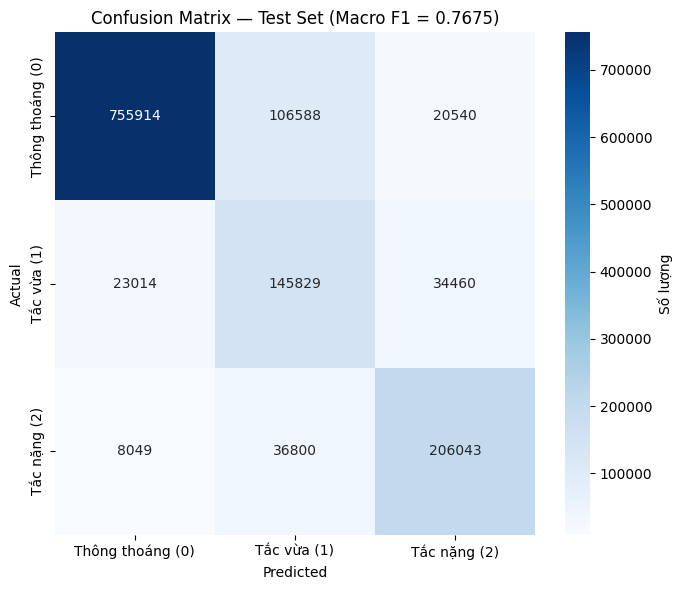

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Lấy confusion matrix dạng đầy đủ (3x3) từ predictions Test
cm_pdf = (pred_test
    .groupBy(label_col, "prediction")
    .count()
    .toPandas())

classes = [0.0, 1.0, 2.0]
class_names = ["Thông thoáng (0)", "Tắc vừa (1)", "Tắc nặng (2)"]

cm_matrix = np.zeros((3, 3))
for _, row in cm_pdf.iterrows():
    true_idx = classes.index(row[label_col])
    pred_idx = classes.index(row["prediction"])
    cm_matrix[true_idx, pred_idx] = row["count"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_matrix.astype(int),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
    cbar_kws={"label": "Số lượng"},
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — Test Set (Macro F1 = {macro_f1_test:.4f})")
plt.tight_layout()
plt.show()

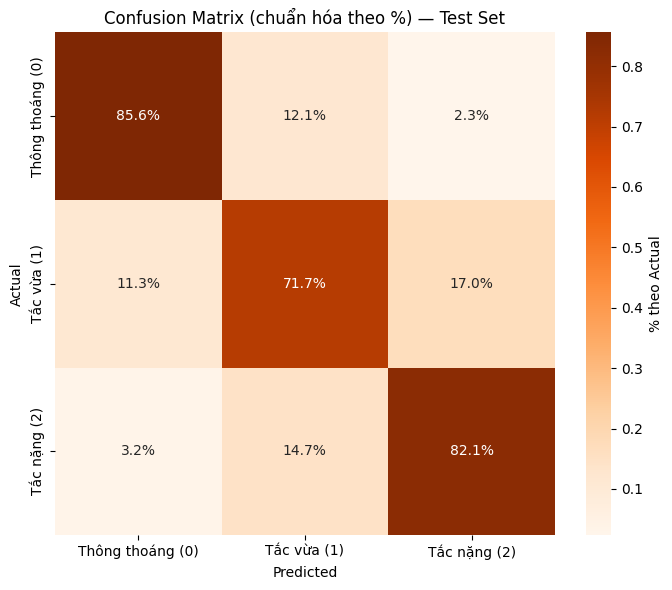

In [ ]:
cm_normalized = cm_matrix / cm_matrix.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_normalized,
    annot=True, fmt=".1%", cmap="Oranges",
    xticklabels=class_names, yticklabels=class_names,
    cbar_kws={"label": "% theo Actual"},
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (chuẩn hóa theo %) — Test Set")
plt.tight_layout()
plt.show()

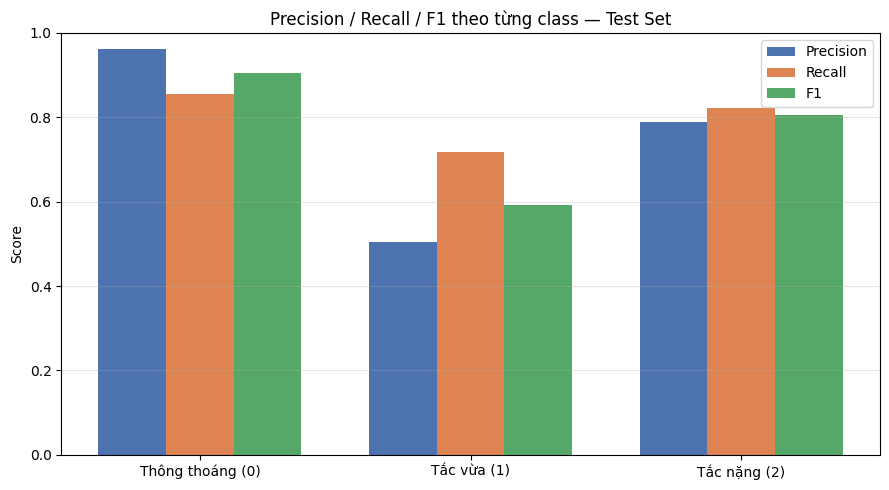

In [ ]:
metrics_pdf = metrics_test_df.orderBy("class").toPandas()
metrics_pdf["class_name"] = class_names

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(class_names))
width = 0.25

ax.bar(x - width, metrics_pdf["precision"], width, label="Precision", color="#4C72B0")
ax.bar(x,         metrics_pdf["recall"],    width, label="Recall",    color="#DD8452")
ax.bar(x + width, metrics_pdf["f1"],        width, label="F1",        color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 theo từng class — Test Set")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

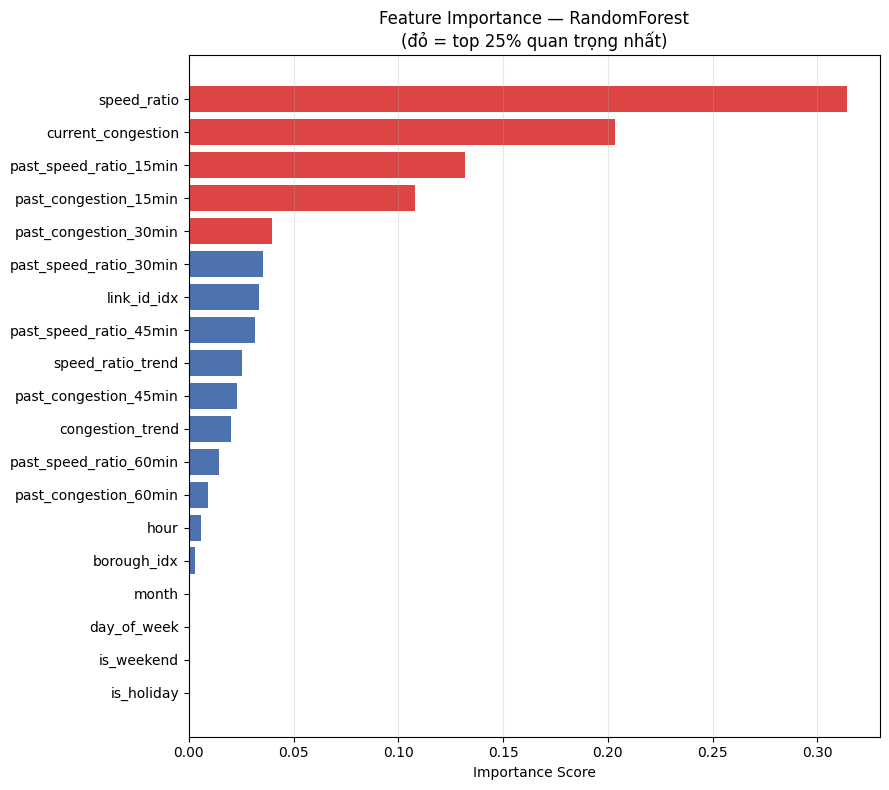


Top 5 feature quan trọng nhất:
               feature  importance
 past_congestion_30min    0.039878
 past_congestion_15min    0.108052
past_speed_ratio_15min    0.131761
    current_congestion    0.203324
           speed_ratio    0.314145


In [ ]:
# Feature Importance
rf_model = model.stages[-1]
importances = rf_model.featureImportances.toArray()

feature_names = ["link_id_idx", "borough_idx"] + numeric_features
importance_pdf = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#4C72B0" if imp < importance_pdf["importance"].quantile(0.75) else "#DD4444"
          for imp in importance_pdf["importance"]]
ax.barh(importance_pdf["feature"], importance_pdf["importance"], color=colors)
ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance — RandomForest\n(đỏ = top 25% quan trọng nhất)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 feature quan trọng nhất:")
print(importance_pdf.tail(5)[["feature", "importance"]].to_string(index=False))

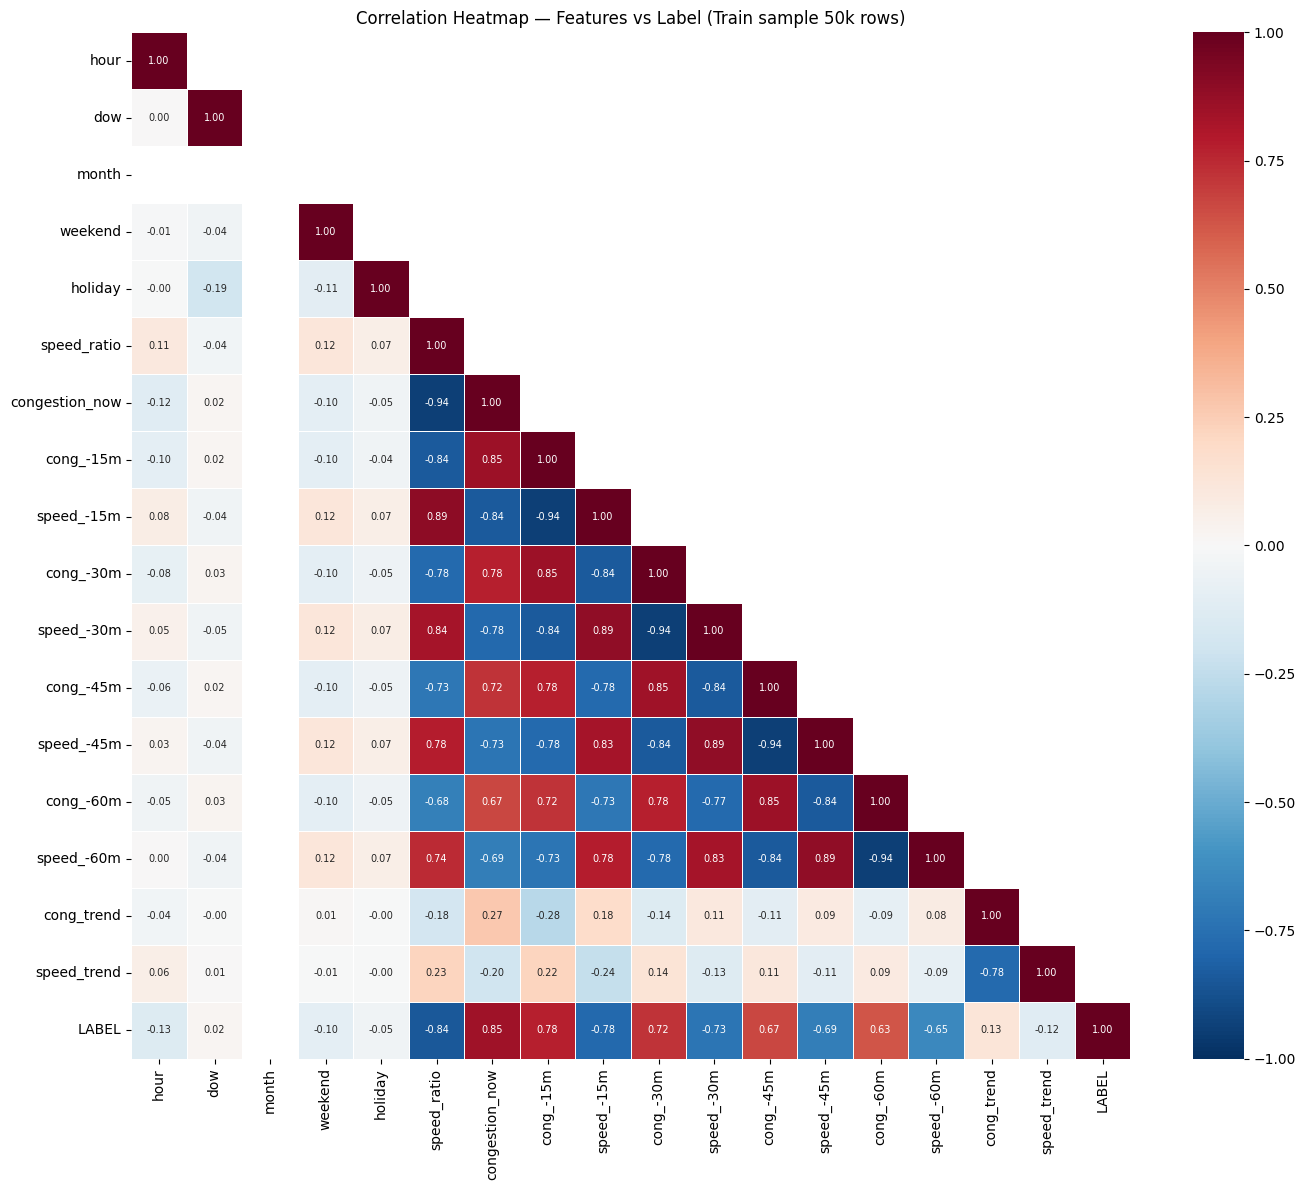


Correlation của từng feature với LABEL (future_congestion_15min):
congestion_now    0.851238
speed_ratio      -0.844089
speed_-15m       -0.782871
cong_-15m         0.778519
speed_-30m       -0.733833
cong_-30m         0.722680
speed_-45m       -0.688619
cong_-45m         0.671389
speed_-60m       -0.645920
cong_-60m         0.626457
hour             -0.133875
cong_trend        0.130657
speed_trend      -0.124246
weekend          -0.095488
holiday          -0.045319
dow               0.019440
month                  NaN


In [ ]:
# Correlation heatmap — các feature tương quan thế nào với nhau và với label
# Lấy sample nhỏ của Train để tính correlation (không cần full data)
corr_cols = numeric_features + [label_col]

df_corr_sample = df_train.select(*corr_cols).limit(50000).toPandas()
df_corr_sample = df_corr_sample.apply(pd.to_numeric, errors="coerce")

corr_matrix = df_corr_sample.corr()

# Đổi tên cột ngắn hơn cho dễ đọc trên chart
short_names = {
    "hour": "hour",
    "day_of_week": "dow",
    "month": "month",
    "is_weekend": "weekend",
    "is_holiday": "holiday",
    "speed_ratio": "speed_ratio",
    "current_congestion": "congestion_now",
    "past_congestion_15min": "cong_-15m",
    "past_speed_ratio_15min": "speed_-15m",
    "past_congestion_30min": "cong_-30m",
    "past_speed_ratio_30min": "speed_-30m",
    "past_congestion_45min": "cong_-45m",
    "past_speed_ratio_45min": "speed_-45m",
    "past_congestion_60min": "cong_-60m",
    "past_speed_ratio_60min": "speed_-60m",
    "congestion_trend": "cong_trend",
    "speed_ratio_trend": "speed_trend",
    label_col: "LABEL",
}
corr_matrix = corr_matrix.rename(columns=short_names, index=short_names)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # ẩn tam giác trên tránh redundant

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    ax=ax
)
ax.set_title("Correlation Heatmap — Features vs Label (Train sample 50k rows)")
plt.tight_layout()
plt.show()

# In riêng correlation với label để dễ nhìn thứ tự ảnh hưởng
print("\nCorrelation của từng feature với LABEL (future_congestion_15min):")
label_corr = corr_matrix["LABEL"].drop("LABEL").sort_values(key=abs, ascending=False)
print(label_corr.to_string())

Bắt đầu lưu model

In [ ]:
MODEL_PATH = f"{BASE_PATH}/artifacts/model/random_forest_model"

In [ ]:
# Xóa model cũ trên Azure trước khi lưu mới — tránh rác do hash stage thay đổi giữa các lần fit
from azure.storage.blob import BlobServiceClient

CONN_STR = f"DefaultEndpointsProtocol=https;AccountName={ACCOUNT_NAME};AccountKey={ACCOUNT_KEY};EndpointSuffix=core.windows.net"
BLOB_MODEL_PREFIX = "artifacts/model/random_forest_model"

container_client = BlobServiceClient.from_connection_string(CONN_STR).get_container_client(CONTAINER)
old_blobs = list(container_client.list_blobs(name_starts_with=BLOB_MODEL_PREFIX))
for b in old_blobs:
    container_client.delete_blob(b.name)
print(f"Đã xóa {len(old_blobs)} file model cũ trên Azure")

Đã xóa 36 file model cũ trên Azure


In [ ]:
# Save model trực tiếp lên Azure Blob
model.write().overwrite().save(MODEL_PATH)

print(" Đã save model lên:")
print(MODEL_PATH)

 Đã save model lên:
wasbs://nyc-traffic-lakehouse@nyctrafficlakehouse.blob.core.windows.net/artifacts/model/random_forest_model


In [ ]:
from pyspark.ml import PipelineModel

loaded_model = PipelineModel.load(MODEL_PATH)

print(" Load model OK")
print("Spark version:", spark.version)

 Load model OK
Spark version: 4.0.0


In [ ]:
quick_val = df_val.select(*(feature_cols + [label_col])).limit(20)
quick_pred = loaded_model.transform(quick_val).select(
    "link_id", "borough", label_col, "prediction", "probability"
)
quick_pred.show(30, truncate=False)

+-------+-------+-----------------------+----------+-------------------------------------------------------------+
|link_id|borough|future_congestion_15min|prediction|probability                                                  |
+-------+-------+-----------------------+----------+-------------------------------------------------------------+
|4616261|Bronx  |0.0                    |1.0       |[0.03012585422875408,0.7078726116357952,0.26200153413545085] |
|4616261|Bronx  |0.0                    |1.0       |[0.09760935432597438,0.8206237369028695,0.08176690877115605] |
|4362251|Queens |0.0                    |0.0       |[0.9579730941917652,0.03245178133784954,0.00957512447038524] |
|4362251|Queens |0.0                    |0.0       |[0.9572539465422679,0.03309779045804224,0.009648262999689843]|
|4362251|Queens |0.0                    |0.0       |[0.9579730941917652,0.03245178133784954,0.00957512447038524] |
|4616261|Bronx  |0.0                    |0.0       |[0.800070442148283,0.1731109

In [ ]:
print("=== VERIFY 4 ARTIFACTS TRÊN AZURE BLOB ===\n")

from azure.storage.blob import BlobServiceClient

CONN_STR = (
    f"DefaultEndpointsProtocol=https;"
    f"AccountName={ACCOUNT_NAME};"
    f"AccountKey={ACCOUNT_KEY};"
    f"EndpointSuffix=core.windows.net"
)

blob_service = BlobServiceClient.from_connection_string(CONN_STR)
container_client = blob_service.get_container_client(CONTAINER)

artifacts_to_check = [
    {
        "name": "Random Forest model",
        "path": "artifacts/model/random_forest_model/",
        "type": "prefix"
    },
    {
        "name": "Free-flow speed lookup",
        "path": "artifacts/free_flow_speed_lookup.parquet",
        "type": "prefix"
    },
    {
        "name": "Active link IDs",
        "path": "artifacts/active_link_ids.json",
        "type": "file"
    },
    {
        "name": "Link coordinates",
        "path": "artifacts/link_coordinates.parquet",
        "type": "prefix"
    },
]

all_ok = True

for artifact in artifacts_to_check:
    name = artifact["name"]
    path = artifact["path"]
    check_type = artifact["type"]

    if check_type == "file":
        # Kiểm tra đúng 1 file exact path
        blob_client = container_client.get_blob_client(path)

        try:
            props = blob_client.get_blob_properties()
            print(f" {name}")
            print(f"   Path: {path}")
            print(f"   Size: {props.size:,} bytes\n")
        except Exception:
            print(f" {name}")
            print(f"   Path: {path}")
            print("   KHÔNG TÌM THẤY\n")
            all_ok = False

    else:
        # Kiểm tra thư mục/prefix, ví dụ Spark model hoặc parquet folder
        blobs = list(container_client.list_blobs(name_starts_with=path))

        if len(blobs) > 0:
            total_size = sum(b.size for b in blobs)
            print(f" {name}")
            print(f"   Prefix: {path}")
            print(f"   Files: {len(blobs)}")
            print(f"   Total size: {total_size:,} bytes\n")
        else:
            print(f" {name}")
            print(f"   Prefix: {path}")
            print("   KHÔNG TÌM THẤY\n")
            all_ok = False

if all_ok:
    print("Đã có đủ 4 artifacts trên Azure Blob.")
else:
    print("Chưa đủ artifacts. Cần kiểm tra lại bước upload.")

=== VERIFY 4 ARTIFACTS TRÊN AZURE BLOB ===

 Random Forest model
   Prefix: artifacts/model/random_forest_model/
   Files: 50
   Total size: 13,687,198 bytes

 Free-flow speed lookup
   Prefix: artifacts/free_flow_speed_lookup.parquet
   Files: 1
   Total size: 6,875 bytes

 Active link IDs
   Path: artifacts/active_link_ids.json
   Size: 1,375 bytes

 Link coordinates
   Prefix: artifacts/link_coordinates.parquet
   Files: 1
   Total size: 5,022 bytes

Đã có đủ 4 artifacts trên Azure Blob.


In [ ]:
# Kiểm tra phân phối (distribution) của 'hour' trên 3 tập train/val/test
print("=== Phân phối HOUR - Train ===")
df_train.groupBy("hour").count().orderBy("hour").show(24)

print("=== Phân phối HOUR - Val ===")
df_val.groupBy("hour").count().orderBy("hour").show(24)

print("=== Phân phối HOUR - Test ===")
df_test.groupBy("hour").count().orderBy("hour").show(24)

# Phân phối dạng tỉ lệ % để so sánh dễ hơn giữa các tập (đề phòng lệch phân phối theo giờ)
from pyspark.sql import functions as F

def hour_distribution_pct(df, name):
    total = df.count()
    dist = (
        df.groupBy("hour")
          .count()
          .withColumn("pct", F.round(F.col("count") * 100.0 / F.lit(total), 3))
          .orderBy("hour")
    )
    print(f"--- {name} (tổng {total:,} dòng) ---")
    dist.show(24)
    return dist

dist_train = hour_distribution_pct(df_train, "Train")
dist_val = hour_distribution_pct(df_val, "Val")
dist_test = hour_distribution_pct(df_test, "Test")


=== Phân phối HOUR - Train ===
+----+------+
|hour| count|
+----+------+
| 0.0|214529|
| 1.0|223827|
| 2.0|232010|
| 3.0|235848|
| 4.0|236883|
| 5.0|237287|
| 6.0|237074|
| 7.0|235811|
| 8.0|236949|
| 9.0|238947|
|10.0|237318|
|11.0|237101|
|12.0|237879|
|13.0|237407|
|14.0|238655|
|15.0|238979|
|16.0|237319|
|17.0|228586|
|18.0|221627|
|19.0|224459|
|20.0|223845|
|21.0|216201|
|22.0|210962|
|23.0|209148|
+----+------+

=== Phân phối HOUR - Val ===
+----+-----+
|hour|count|
+----+-----+
| 0.0|31450|
| 1.0|33085|
| 2.0|33541|
| 3.0|34176|
| 4.0|34291|
| 5.0|34466|
| 6.0|34742|
| 7.0|33893|
| 8.0|33881|
| 9.0|34123|
|10.0|33757|
|11.0|34172|
|12.0|33538|
|13.0|34241|
|14.0|34811|
|15.0|33922|
|16.0|34277|
|17.0|33640|
|18.0|33500|
|19.0|32729|
|20.0|30731|
|21.0|29622|
|22.0|29235|
|23.0|30185|
+----+-----+

=== Phân phối HOUR - Test ===
+----+-----+
|hour|count|
+----+-----+
| 0.0|53222|
| 1.0|54813|
| 2.0|56534|
| 3.0|57592|
| 4.0|57690|
| 5.0|57505|
| 6.0|55874|
| 7.0|54839|
| 8.0|548

In [ ]:
# Kiểm tra phân phối (distribution) của 'month' trên 3 tập train/val/test
print("=== Phân phối MONTH - Train ===")
df_train.groupBy("month").count().orderBy("month").show(12)

print("=== Phân phối MONTH - Val ===")
df_val.groupBy("month").count().orderBy("month").show(12)

print("=== Phân phối MONTH - Test ===")
df_test.groupBy("month").count().orderBy("month").show(12)

def month_distribution_pct(df, name):
    total = df.count()
    dist = (
        df.groupBy("month")
          .count()
          .withColumn("pct", F.round(F.col("count") * 100.0 / F.lit(total), 3))
          .orderBy("month")
    )
    print(f"--- {name} (tổng {total:,} dòng) ---")
    dist.show(12)
    return dist

dist_month_train = month_distribution_pct(df_train, "Train")
dist_month_val = month_distribution_pct(df_val, "Val")
dist_month_test = month_distribution_pct(df_test, "Test")

=== Phân phối MONTH - Train ===
+-----+------+
|month| count|
+-----+------+
|  1.0|557686|
|  2.0|403744|
|  3.0|548695|
|  4.0|540139|
|  5.0|533152|
|  6.0|514186|
|  7.0|538147|
|  8.0|545505|
|  9.0|549394|
| 10.0|286594|
| 11.0|277878|
| 12.0|233531|
+-----+------+

=== Phân phối MONTH - Val ===
+-----+------+
|month| count|
+-----+------+
| 10.0|273424|
| 11.0|255411|
| 12.0|267173|
+-----+------+

=== Phân phối MONTH - Test ===
+-----+------+
|month| count|
+-----+------+
|  1.0|285532|
|  2.0|241065|
|  3.0|224194|
|  4.0|173639|
|  5.0|241512|
|  6.0|171295|
+-----+------+

--- Train (tổng 5,528,651 dòng) ---
+-----+------+------+
|month| count|   pct|
+-----+------+------+
|  1.0|557686|10.087|
|  2.0|403744| 7.303|
|  3.0|548695| 9.925|
|  4.0|540139|  9.77|
|  5.0|533152| 9.643|
|  6.0|514186|   9.3|
|  7.0|538147| 9.734|
|  8.0|545505| 9.867|
|  9.0|549394| 9.937|
| 10.0|286594| 5.184|
| 11.0|277878| 5.026|
| 12.0|233531| 4.224|
+-----+------+------+

--- Val (tổng 796,00